In [163]:
# # AirCast AI
# ## Air Quality Index Prediction & Time-Series Forecasting

# ### Objective

# To clean air-quality monitoring data and develop machine learning
# and time-series models for predicting Air Quality Index (AQI).

# ### Main Focus
# 1. Data Cleaning
# 2. Feature Preparation
# 3. Model Training
# 4. Model Evaluation
# 5. AQI Forecasting

# ### Target Variable
# AQI

# ### Input Pollutants
# - PM2.5
# - PM10
# - NO2
# - NH3
# - SO2
# - CO
# - OZONE

In [164]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [165]:
df = pd.read_csv("../Dataset/dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (492, 27)


In [166]:
df.head()

,Station,LastUpdate,Latitude,Longitude,PM2.5_Min,PM2.5_Max,PM2.5_Avg,PM10_Min,PM10_Max,PM10_Avg,...,SO2_Max,SO2_Avg,CO_Min,CO_Max,CO_Avg,OZONE_Min,OZONE_Max,OZONE_Avg,AQI,Predominant_Parameter
0,"Secretariat, Amaravati - APPCB",20-11-2023 12:00:00,16.515083,80.518167,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Gulzarpet, Anantapur - APPCB",20-11-2023 12:00:00,14.675886,77.593027,15.0,34.0,24.0,16.0,39.0,24.0,...,17.0,7.0,20.0,40.0,29.0,16.0,52.0,25.0,29.0,CO
2,"Gangineni Cheruvu, Chittoor - APPCB",20-11-2023 12:00:00,13.204880,79.097889,11.0,30.0,19.0,13.0,35.0,22.0,...,18.0,9.0,2.0,5.0,4.0,23.0,92.0,35.0,35.0,OZONE
3,"Yerramukkapalli, Kadapa - APPCB",20-11-2023 12:00:00,14.465052,78.824187,19.0,57.0,37.0,18.0,48.0,32.0,...,2.0,2.0,12.0,30.0,21.0,6.0,48.0,21.0,37.0,PM2.5
4,"Anand Kala Kshetram, Rajamahendravaram - APPCB",20-11-2023 12:00:00,16.987287,81.736318,31.0,72.0,44.0,43.0,101.0,58.0,...,15.0,12.0,6.0,48.0,24.0,20.0,43.0,28.0,58.0,PM10


In [167]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
Station
LastUpdate
Latitude
Longitude
PM2.5_Min
PM2.5_Max
PM2.5_Avg
PM10_Min
PM10_Max
PM10_Avg
NO2_Min
NO2_Max
NO2_Avg
NH3_Min
NH3_Max
NH3_Avg
SO2_Min
SO2_Max
SO2_Avg
CO_Min
CO_Max
CO_Avg
OZONE_Min
OZONE_Max
OZONE_Avg
AQI
Predominant_Parameter


In [168]:
df.columns = df.columns.str.strip()

df["Station"] = df["Station"].astype(str).str.strip()
df["Predominant_Parameter"] = (
    df["Predominant_Parameter"]
    .astype(str)
    .str.strip()
)

print("Column names cleaned.")

Column names cleaned.


In [169]:
df = df.replace(
    ["NA", "N/A", "na", "null", "NULL", ""],
    np.nan
)

print("NA values converted to NaN.")

NA values converted to NaN.


In [170]:
df["LastUpdate"] = pd.to_datetime(
    df["LastUpdate"],
    format="%d-%m-%Y %H:%M:%S",
    errors="coerce"
)

print(df["LastUpdate"].head())

0   2023-11-20 12:00:00
1   2023-11-20 12:00:00
2   2023-11-20 12:00:00
3   2023-11-20 12:00:00
4   2023-11-20 12:00:00
Name: LastUpdate, dtype: datetime64[ns]


In [171]:
numeric_columns = [
    "Latitude",
    "Longitude",

    "PM2.5_Min",
    "PM2.5_Max",
    "PM2.5_Avg",

    "PM10_Min",
    "PM10_Max",
    "PM10_Avg",

    "NO2_Min",
    "NO2_Max",
    "NO2_Avg",

    "NH3_Min",
    "NH3_Max",
    "NH3_Avg",

    "SO2_Min",
    "SO2_Max",
    "SO2_Avg",

    "CO_Min",
    "CO_Max",
    "CO_Avg",

    "OZONE_Min",
    "OZONE_Max",
    "OZONE_Avg",

    "AQI"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Numerical columns converted.")

Numerical columns converted.


In [172]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

missing.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
NH3_Avg,99,20.121951
NH3_Min,99,20.121951
NH3_Max,99,20.121951
SO2_Min,61,12.398374
SO2_Max,61,12.398374
SO2_Avg,61,12.398374
NO2_Max,50,10.162602
PM10_Min,50,10.162602
PM10_Max,50,10.162602
PM10_Avg,50,10.162602


In [173]:
print("Rows before removing missing AQI:",
      len(df))

df = df.dropna(subset=["AQI"])

print("Rows after removing missing AQI:",
      len(df))

Rows before removing missing AQI: 492
Rows after removing missing AQI: 454


In [174]:
print("Duplicate rows before:",
      df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after:",
      df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


In [175]:
features = [
    "PM2.5_Avg",
    "PM10_Avg",
    "NO2_Avg",
    "NH3_Avg",
    "SO2_Avg",
    "CO_Avg",
    "OZONE_Avg"
]

target = "AQI"

print("Features:")
print(features)

print("\nTarget:")
print(target)

Features:
['PM2.5_Avg', 'PM10_Avg', 'NO2_Avg', 'NH3_Avg', 'SO2_Avg', 'CO_Avg', 'OZONE_Avg']

Target:
AQI


In [176]:
for column in features:
    df[column] = df[column].fillna(
        df[column].median()
    )

print("Missing pollutant values filled using median.")

Missing pollutant values filled using median.


In [177]:
print(df[features + ["AQI"]].isnull().sum())

PM2.5_Avg    0
PM10_Avg     0
NO2_Avg      0
NH3_Avg      0
SO2_Avg      0
CO_Avg       0
OZONE_Avg    0
AQI          0
dtype: int64


In [178]:
X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (454, 7)
y shape: (454,)


In [179]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 363
Testing samples: 91


In [180]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [181]:
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [182]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("========== MODEL PERFORMANCE ==========")
print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))
print("R²   :", round(r2, 4))

========== MODEL PERFORMANCE ==========
MAE  : 4.367
RMSE : 7.7096
R²   : 0.9938


In [183]:
results = pd.DataFrame({
    "Actual_AQI": y_test.values,
    "Predicted_AQI": y_pred
})

results.head(20)

,Actual_AQI,Predicted_AQI
0,87.0,88.743333
1,222.0,227.190000
2,204.0,204.616667
3,182.0,181.193333
4,71.0,74.340000
5,143.0,143.480000
6,92.0,92.493333
7,187.0,183.036667
8,297.0,298.856667
9,158.0,156.260000


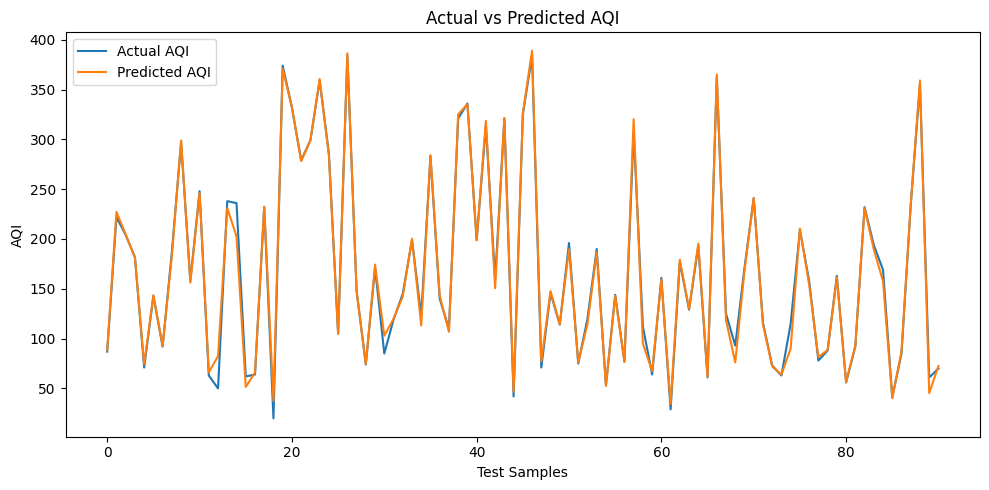

In [184]:
plt.figure(figsize=(10, 5))

plt.plot(
    results["Actual_AQI"].values,
    label="Actual AQI"
)

plt.plot(
    results["Predicted_AQI"].values,
    label="Predicted AQI"
)

plt.title("Actual vs Predicted AQI")
plt.xlabel("Test Samples")
plt.ylabel("AQI")
plt.legend()

plt.tight_layout()
plt.show()

In [185]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,PM2.5_Avg,0.895649
1,PM10_Avg,0.099640
5,CO_Avg,0.001179
2,NO2_Avg,0.001111
6,OZONE_Avg,0.000844
4,SO2_Avg,0.000837
3,NH3_Avg,0.000739


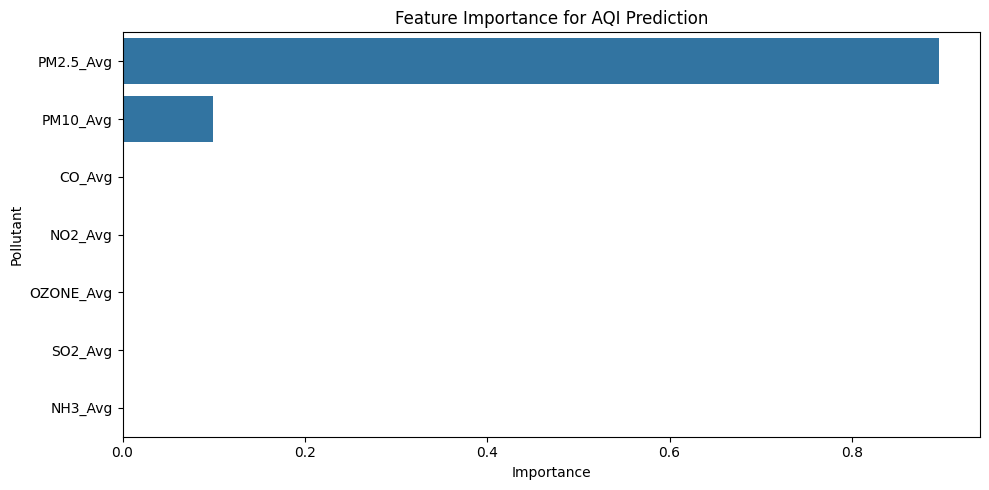

In [186]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for AQI Prediction")
plt.xlabel("Importance")
plt.ylabel("Pollutant")

plt.tight_layout()
plt.show()

In [187]:
import joblib
joblib.dump(
    rf_model,
    "../model/aqi_random_forest.pkl"
)

print("Model saved successfully!")
print(feature_importance)




Model saved successfully!
     Feature  Importance
0  PM2.5_Avg    0.895649
1   PM10_Avg    0.099640
5     CO_Avg    0.001179
2    NO2_Avg    0.001111
6  OZONE_Avg    0.000844
4    SO2_Avg    0.000837
3    NH3_Avg    0.000739


In [188]:
df.to_csv(
    "../Dataset/air_quality_cleaned.csv",
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


In [189]:
unique_dates = df["LastUpdate"].nunique()

print("Unique timestamps:", unique_dates)

Unique timestamps: 1


In [190]:
if unique_dates <= 1:

    print("""
    ⚠️ TIME-SERIES FORECASTING CANNOT BE TRAINED
    ---------------------------------------------
    Current dataset contains only one timestamp.

    ARIMA/VAR require multiple historical timestamps.

    The Random Forest AQI prediction model above
    has been trained successfully using pollutant features.
    """)

else:

    print("""
    ✅ Multiple timestamps found.
    Time-series forecasting can be performed.
    """)


    ⚠️ TIME-SERIES FORECASTING CANNOT BE TRAINED
    ---------------------------------------------
    Current dataset contains only one timestamp.

    ARIMA/VAR require multiple historical timestamps.

    The Random Forest AQI prediction model above
    has been trained successfully using pollutant features.
    


In [191]:
print("Unique timestamps:", df["LastUpdate"].nunique())

Unique timestamps: 1


In [192]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [193]:
nn_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)
])

In [194]:
nn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [195]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 36315.7656 - mae: 162.1862 - val_loss: 31024.3809 - val_mae: 147.5980
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 35956.6914 - mae: 161.2329 - val_loss: 30655.0898 - val_mae: 146.5286
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 35388.8477 - mae: 159.7749 - val_loss: 30040.2676 - val_mae: 144.8421
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 34460.2422 - mae: 157.4829 - val_loss: 29133.4082 - val_mae: 142.3616
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33127.8945 - mae: 154.1537 - val_loss: 27809.0996 - val_mae: 138.7505
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31118.7422 - mae: 149.1464 - val_loss: 25979.4961 - val_mae: 133.7115
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 28554.2285 - mae: 142.5939 - val_loss: 23598.5254 - val_mae: 127.0214
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25363.4219 - mae: 134.0403 - val_los

In [196]:
nn_pred = nn_model.predict(X_test_scaled).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [197]:
nn_mae = mean_absolute_error(y_test, nn_pred)

nn_rmse = np.sqrt(
    mean_squared_error(y_test, nn_pred)
)

nn_r2 = r2_score(y_test, nn_pred)

print("Neural Network MAE:", nn_mae)
print("Neural Network RMSE:", nn_rmse)
print("Neural Network R2 Score:", nn_r2)

Neural Network MAE: 8.986957047011826
Neural Network RMSE: 13.142440304585598
Neural Network R2 Score: 0.9819157150479528


In [198]:
model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Neural Network"],
    "MAE": [mae, nn_mae],
    "RMSE": [rmse, nn_rmse],
    "R2": [r2, nn_r2]
})

print(model_comparison)

            Model       MAE       RMSE        R2
0   Random Forest  4.366960   7.709597  0.993777
1  Neural Network  8.986957  13.142440  0.981916


In [199]:
nn_model.save("../model/aqi_neural_network.keras")
joblib.dump(scaler, "../model/nn_scaler.pkl")

['../model/nn_scaler.pkl']

In [200]:
print("""
=========================================
        AIRCAST AI - FINAL SUMMARY
=========================================

DATASET
-------
Rows              : {}
Columns           : {}

MODEL
-----
Random Forest AQI Prediction
Target            : AQI

FEATURES
--------
PM2.5
PM10
NO2
NH3
SO2
CO
OZONE

EVALUATION
----------
MAE               : {:.4f}
RMSE              : {:.4f}
R2                : {:.4f}

TIME SERIES
-----------
Unique Timestamps : {}

=========================================
""".format(
    len(df),
    df.shape[1],
    mae,
    rmse,
    r2,
    df["LastUpdate"].nunique()
))


        AIRCAST AI - FINAL SUMMARY

DATASET
-------
Rows              : 454
Columns           : 27

MODEL
-----
Random Forest AQI Prediction
Target            : AQI

FEATURES
--------
PM2.5
PM10
NO2
NH3
SO2
CO
OZONE

EVALUATION
----------
MAE               : 4.3670
RMSE              : 7.7096
R2                : 0.9938

TIME SERIES
-----------
Unique Timestamps : 1


